# Tweet Sentiment Analysis using NLP

## Business Understanding
Titan Electronic Company is a company that retails high-end products such as iPhones, iPads and other premium electronic products. It operates in a quite competititive market where customer perception directly influences sales, brand loyalty and market share. Because the products that the company sells are quite expensive, customers ften tend to be very expressive and critical about their experience using the said products.

Social media platforms like X(Twitter) is one of the major platforms where the customers channel their feedback publicly, making it a very valuable source of real-time data for Titan Electronic Company. However, the company cannot analyze the tens of thousands of comments from the various social media platforms since it will be expensive, impractical and inefficient.

To address this challenge, Titan Electronic requires an automated NLP model that will help them classify the tweets into Negative, Positive or Neutral categories. By filtering out irrelevant banter in tweets, the marketing and inventory team can quickly pick consumer trends and mitigate any impending negative pubicity and also leverage on positive sentiment.

Using data from the social media platforms will help in creating actionable insights that will help Titan Electronic optimize it's marketing strategy, arrest any looming negative perceptions of it's products and always have a competitive edge and share in the market.


## Problem statement
Titan Electronic faces the challenge of tracking customer sentiments due to the overwhelmiing number of tweets they receive in their social media platforms. **The company therefore needs to develop a robust sentiment analysis model capable of accurately classifying the emotions accurately from the noisy text.** The tweets also present challenges that can hinder model performance as the tweets also have slang, punctuations, sarcasm, abbreviations and class imbalance. 

Therefore, the company's real problem is to build an effective system that can extract meaningful insights, and allow the company monitor customer sentiments and improve their decision making.


## Business Objectives
The main objectives of the project is to build an automated machine learning that will be able to classify the tweets as begative, positive, or neutral:
- Understand customers opinion and emotions towards the products/brand
- Monitor brand reputation in real time from tweets in their Twitter page
- Support data driven decision making in product development and marketing by identifying customer trends to optimize and guide marketing strategy
- Develop a model that can handle large volumes of tweets

## Imports

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('wordnet')
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from nltk.stem import WordNetLemmatizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from collections import Counter
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\KEN18237\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\KEN18237\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Data Understanding
The dataset contains tweets about iPhone, Google an Apple products from customers. Each row represents a single tweet made by a customer.

- **tweet text**: contents of the tweet
- **emotion_in_tweet_is_directed_at**: brand or product of which the tweet is about.
- **is_there_an_emotion_directed_at_a_brand_or_product**: the sentiment of the tweet either positive, negative or neutral.

Undestanding the contents of the tweets and what the columnns enntail is crucial before any preprocessing is done.

In [ ]:
# Loading the dataset
df = pd.read_csv('../data/judge-1377884607_tweet_product_company.csv',encoding='latin1')
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [ ]:
df.describe()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
count,9092,3291,9093
unique,9065,9,4
top,RT @mention Marissa Mayer: Google Will Connect...,iPad,No emotion toward brand or product
freq,5,946,5389


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9093 entries, 0 to 9092
Data columns (total 3 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          9092 non-null   object
 1   emotion_in_tweet_is_directed_at                     3291 non-null   object
 2   is_there_an_emotion_directed_at_a_brand_or_product  9093 non-null   object
dtypes: object(3)
memory usage: 213.2+ KB


In [ ]:
df.shape

(9093, 3)

## Observations and reasons on how data will be cleaned.
We loaded the dataset **judge-1377884607_tweet_product_company.csv** and inspected its structure, shape and the datatype it contained.

**Shape and Data types**
 The dataset contains 9,093 rows and 3 columns
 - **tweet text**: contents of the tweet
 - **emotion_in_tweet_is_directed_at**: brand ot product of which the tweet is about
 - **is_there_an_emotion_directed_at_a_brand_or_product**: the sentiment of the tweet either positive, negative or neutral.

**Missing values**
 - **tweet text** column has only one missing value. The missing value will be dropped

 - **emotion_in_tweet_is_directed_at** column has **5,802 missing values** . We will not drop the missing values because the metadata from that column is optional and therefore wont be used. Since the missing values and over 60%, dropping them could ultimately affect model training

 - **is_there_an_emotion_directed_at_a_brand_or_product** column has no missing values

 **Duplicates**
  - There are 27 duplicate rows in the dataset. These will be dropped to prevent the model from learning repetitive data.

**Accuracy of sentiment labels**
 - The sentiment columns contains the following labels **negative emotion**, **positive emotion**, and **neutral emotion towards the brand or product**
  - The is one label **"I can't tell "** which will be dropped. This is because its ambiguous and does not provide a clear sentiment. Keeping it may introduce noice to the model which might reduce model performance.

In [ ]:
df.isnull().sum() ## check for null entries

tweet_text                                               1
emotion_in_tweet_is_directed_at                       5802
is_there_an_emotion_directed_at_a_brand_or_product       0
dtype: int64

In [ ]:
# dealing with the missing values. Do we drop of fill?
# for tweet, we will drop that one missing value

df = df.dropna(subset=['tweet_text']) # dropped the one missing tweet
df.isnull().sum() 

tweet_text                                               0
emotion_in_tweet_is_directed_at                       5801
is_there_an_emotion_directed_at_a_brand_or_product       0
dtype: int64

In [ ]:
# Duplicates
duplicates = df['tweet_text'].duplicated().sum()  # check for duplicates in the 'tweet' column
print(f"Duplicate tweets: {duplicates}")
df = df.drop_duplicates(subset='tweet_text').reset_index(drop=True) # drop duplicates based on the 'tweet' column and reset index
print(f"Shape after removing duplicates: {df.shape}")

Duplicate tweets: 27
Shape after removing duplicates: (9065, 3)


In [ ]:
## Normalizing sentiment labels and removing "I can't tell" entries
df['is_there_an_emotion_directed_at_a_brand_or_product'] = df['is_there_an_emotion_directed_at_a_brand_or_product'].str.lower().str.strip()
df = df[df['is_there_an_emotion_directed_at_a_brand_or_product'] != "i can't tell"]

print(f"Shape after removing ambiguous labels: {df.shape}")
print(df['is_there_an_emotion_directed_at_a_brand_or_product'].value_counts())

Shape after removing ambiguous labels: (8909, 3)
no emotion toward brand or product    5372
positive emotion                      2968
negative emotion                       569
Name: is_there_an_emotion_directed_at_a_brand_or_product, dtype: int64


## Data Preparation
In this stage, we will prepare the tweet for NLP modelling. The steps will include: 

1. **Lemmatization**- examines the morphology of the words and reduces each word to its most basic form or lemma eg studies become study.

2. **Lowercasing**- reduces the number of unique words words the model must handle, improves model consistency and ensures the model learns **all occurences of a word together**, and simplifies **text processing**

3. **Tokenization and removing stopwords**-splits the sentences into array of individual words. Stopwords(common words or pretty useless data) that contain litte or no information.

4. **Label Encoding**-a simple and very common technique in Machine Learning to convert **categorical labels**(text) into **numbers**.

5. **Stemming**- stemming refers to the removal of suffixes eg cats to cat.


### Text Cleaning Function

In [ ]:
## Mapping the product names to their respective brands

apple_list = [x.lower() for x in ['iPad', 'Apple', 'iPad app', 'iPhone app', 'iPhone', 'Mac', 'MacBook']]
google_list = [x.lower() for x in ['Google' , 'Android App', 'Android']]

def map_to_brand(product_name):
    if pd.isna(product_name):
        return None
    
    product_name = str(product_name).lower()
    
    if product_name in apple_list:
        return 'Apple'
    elif product_name in google_list:
        return 'Google'
    else:
        return None

df['product'] = df['emotion_in_tweet_is_directed_at'].apply(map_to_brand)

def fill_missing_product(row):
    if pd.notna(row['product']):
        return row['product']
    
    text = str(row['tweet_text']).lower()
    
    if any(word in text for word in ['apple', 'ipad', 'iphone', 'mac']):
        return 'Apple'
    elif any(word in text for word in ['google', 'android', 'pixel']):
        return 'Google'
    else:
        return 'Not specified'

df['product'] = df.apply(fill_missing_product, axis=1)

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def get_clean_tokens(text):
    if not isinstance(text, str):
        return []
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove mentions and hashtag symbols (keep the word)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    # Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    tokens = text.split()
    # Remove stop words
    
    tokens = [word for word in tokens if word not in stop_words]
    # Remove short tokens (1-2 chars)
    tokens = [t for t in tokens if len(t) > 2]
    # Lemmatize tokens
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return tokens

In [ ]:
## Apply the cleaning function to the 'tweet_text' column and create a new column 'clean_text'

df['clean_text'] = df['tweet_text'].apply(lambda x: " ".join(get_clean_tokens(x)))

df[['tweet_text', 'clean_text']].head()

,tweet_text,clean_text
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iphone hr tweeting riseaustin dead need upgrad...
1,@jessedee Know about @fludapp ? Awesome iPad/i...,know awesome ipadiphone app youll likely appre...
2,@swonderlin Can not wait for #iPad 2 also. The...,wait ipad also sale sxsw
3,@sxsw I hope this year's festival isn't as cra...,hope year festival isnt crashy year iphone app...
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,great stuff fri sxsw marissa mayer google tim ...


In [ ]:
positive_emotion = []
negative_emotion = []


for text, is_there_an_emotion_directed_at_a_brand_or_product in zip(df['tweet_text'], df['is_there_an_emotion_directed_at_a_brand_or_product']):
    tokens = get_clean_tokens(text)
    if is_there_an_emotion_directed_at_a_brand_or_product == 'Positive emotion':
        positive_emotion.extend(tokens)

    elif is_there_an_emotion_directed_at_a_brand_or_product == 'Negative emotion':
        negative_emotion.extend(tokens)

# Top 15 Positive tweets
print("\n=== Top 15 Words in POSITIVE Sentiment ===")
print(Counter(positive_emotion).most_common(15))

# Top 15 Negative tweets
print("\n=== Top 15 Words in NEGATIVE Sentiment ===")
print(Counter(negative_emotion).most_common(15))


=== Top 15 Words in POSITIVE Sentiment ===
[]

=== Top 15 Words in NEGATIVE Sentiment ===
[]


## Defining Feature and Target variable

Below, we define the feature(X) and target(y) variables

In [ ]:
X = df['clean_text']
y = df['is_there_an_emotion_directed_at_a_brand_or_product']

### Class Distribution Check
Before we split our data, we examine the distribution of sentiment class. It will help us confrm whethe there exists a class balance and infrm ur choice of modellimg strategy.

In an imbalances dataset, randomly splitting the dataset may cause distortion, leading to biased evaluation results. To curb this, we apply a stratified sampling during the train/test split.


In [ ]:
df['is_there_an_emotion_directed_at_a_brand_or_product'].value_counts(normalize=True) *100

no emotion toward brand or product    60.298574
positive emotion                      33.314626
negative emotion                       6.386800
Name: is_there_an_emotion_directed_at_a_brand_or_product, dtype: float64

We split the dataset into training and test sets using **80/20** split.

Because the classes are inmbalanced, we will apply **the stratifies sampling** to preserve the original class distribution.

A fixed random state will ensure our data is reproducible.

## Train/Test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Modelling
The goal of this section is to build and compare classification models that can accurately predict sentiment from tweet text.

Pipelins will be used in modelling to ensure ther is no **data leakage**


We begin with a baseline model, then introduce more complex models to improve performance.

**TF_IDF**

TF - Maps out the frequency of tokens in our data
IDF - shows the relevance/Weight of words to our target variable

## Baseline Model
### Logistic Regresison + TF-IDF
Logistic Regression was chosen as a simple and interpretable linear model suitable for text classification. It will be combined with TF-IDF.  Combining Logistic Regression or Naive Bayes with TF-IDF is a crucial step in sentiment analysis because TF-IDF turns the raw texts into meaningful numerical features that the model can undeetand. 

Models don't simply undertstand text, they only undertand numbers. TF-IDF converts the tweets into vectors that reflect how important each word is in that tweet relative to the whole corpus. TF-IDF assigns weights to words in our tweets.

**Without TF-IDF, the models will treat all words equally hence poor accuracy. TF-IDF helps makes better predictions for importtant words**

In [ ]:
### Baseline Model = Logistic Regresison with TF-IDF

# Building the full pipeline
pipeline_log= Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('classifier',LogisticRegression())
])

#  training the baseline model
pipeline_log.fit(X_train,y_train)

# predictions
y_pred_baseline = pipeline_log.predict(X_test)

print(f'Baseline Logistic Regression with TFIDF')
print(classification_report(y_test,y_pred_baseline))

print(f'Confusion Matrix')
print(confusion_matrix(y_test,y_pred_baseline))

Baseline Logistic Regression with TFIDF
                                    precision    recall  f1-score   support

                  negative emotion       0.75      0.05      0.10       114
no emotion toward brand or product       0.69      0.88      0.77      1074
                  positive emotion       0.62      0.44      0.51       594

                          accuracy                           0.68      1782
                         macro avg       0.69      0.45      0.46      1782
                      weighted avg       0.67      0.68      0.64      1782

Confusion Matrix
[[  6  83  25]
 [  2 940 132]
 [  0 335 259]]


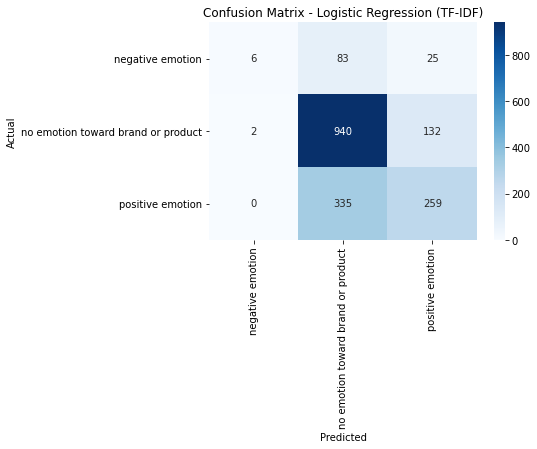

In [ ]:
# Get confusion matrix
cm = confusion_matrix(y_test, y_pred_baseline)


labels = sorted(y_test.unique())

# Plot
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Confusion Matrix - Logistic Regression (TF-IDF)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Interpretation
1. Negative Emotion
  - Precision: 0.75

  - Recall: 0.05
  
  - F1-score- 0.62

  The model performs poorly on negative senetiment. Although the predictions are often correct when it does label somtjing s negative, it often rarely identfies negative cases(very low recall). This leads to misclasification of the negative instances, meaning the model misses nearly all negative sentiments.

  2. Neutral emotion
  - Precision: 0.69

  - Recall: 0.87
  
  - F1-score- 0.77

  The model performs best on the neutral sentiment class with an F1-score of 0.77, driven by high recall(0.87). However, the relatively low precision(0.69) indicates that the model is biased towards predicting the neutral, frequemtly misclassifying both positive and negative tweets as neutral.

2. Positive emotion
  - Precision: 0.62

  - Recall: 0.44
  
  - F1-score- 0.51

  The model perormed poorly on the **positive emotion** with an F1_score of only 0.51. While precision is moderate(0.62), the recall was very low(0.44), indicating the model failed to capture more than half of th actual positive tweets. More positive senttiments were also incorrectly classified as "no emotion towards brand or product". This suggestsa strong bias towards the neutral class, that limits the model ability to detect pstice sentiment effectively.

### Multinomial Naive Bayes 

In [ ]:

# Building the full pipeline
nb_baseline_pipeline= Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('nb',MultinomialNB(alpha=0.5))
])

#  training the baseline model
nb_baseline_pipeline.fit(X_train,y_train)

# predictions
y_pred_nb_baseline = nb_baseline_pipeline.predict(X_test)

print(f'Baseline Naive Bayes with TFIDF')
print(classification_report(y_test,y_pred_nb_baseline))

#Plotting the confusion matrix for the baseline model
print(f'Confusion Matrix')
print(confusion_matrix(y_test,y_pred_baseline))

Baseline Naive Bayes with TFIDF
                                    precision    recall  f1-score   support

                  negative emotion       0.75      0.03      0.05       114
no emotion toward brand or product       0.66      0.91      0.77      1074
                  positive emotion       0.62      0.32      0.42       594

                          accuracy                           0.66      1782
                         macro avg       0.68      0.42      0.41      1782
                      weighted avg       0.65      0.66      0.61      1782

Confusion Matrix
[[  6  83  25]
 [  2 940 132]
 [  0 335 259]]


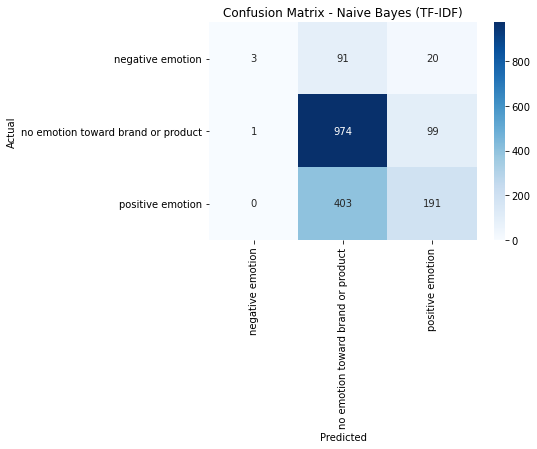

In [ ]:
labels = sorted(y_test.unique())

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_nb_baseline, labels=labels)

# Plot
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Confusion Matrix - Naive Bayes (TF-IDF)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
### Tweaked Logistic Regresison with TF_-IDF


# Building the full pipeline
baseline_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=10000,
        ngram_range =(1,2), # to identify features like "love it", "not good". Helps with negation and sentiment phrase
        min_df=2 
    )),
    ('classifier',LogisticRegression(
        max_iter=1000,
        class_weight ='balanced',  # gives importance to rare classes eg negative emotion
        random_state=42,
        solver='lbfgs'
    ))
])

In [ ]:
# Training our improved baseline model
baseline_pipeline.fit(X_train,y_train)

# Predicting and evaluating the model
y_pred_baseline = baseline_pipeline.predict(X_test)

print(f'Baseline Logistic Regression')
print(classification_report(y_test,y_pred_baseline))

# plotting confusion matrix for the improved baseline model
print(f'Confusion Matrix')
print(confusion_matrix(y_test,y_pred_baseline))

Baseline Logistic Regression
                                    precision    recall  f1-score   support

                  negative emotion       0.33      0.54      0.41       114
no emotion toward brand or product       0.78      0.70      0.73      1074
                  positive emotion       0.58      0.61      0.59       594

                          accuracy                           0.66      1782
                         macro avg       0.56      0.62      0.58      1782
                      weighted avg       0.68      0.66      0.67      1782

Confusion Matrix
[[ 62  33  19]
 [ 76 748 250]
 [ 49 181 364]]


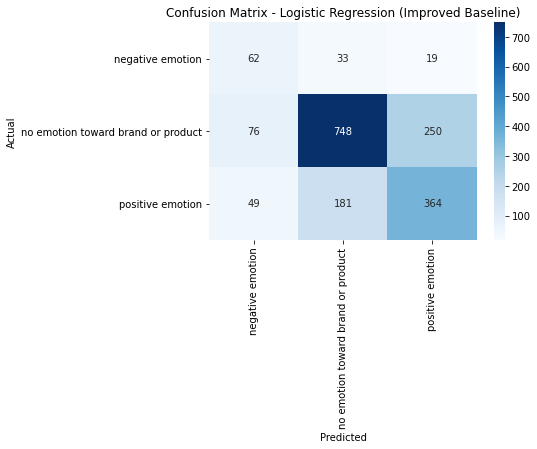

In [ ]:

labels = sorted(y_test.unique())


# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_baseline, labels=labels)

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Confusion Matrix - Logistic Regression (Improved Baseline)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Tweaked version of Naive Bayes with TF-IDF(for comparison)
nb_pipeline = Pipeline([
    ('tidf',TfidfVectorizer(
        max_features=10000,
        ngram_range = (1,2), 
        min_df=2
        )),

    ('nb',MultinomialNB(alpha=0.5))
])

#Training Naive Bayes
nb_pipeline.fit(X_train,y_train)

#Predictions
y_pred_nb= nb_pipeline.predict(X_test)

#printing clasification report for Naives Bayes
print(f'Naive Bayes')
print(classification_report(y_test, y_pred_nb))

# plotting confusion matrix for Naive Bayes
print(f'Confusion Matrix(Naive Bayes):')
print(confusion_matrix(y_test,y_pred_nb))

Naive Bayes
                                    precision    recall  f1-score   support

                  negative emotion       0.83      0.04      0.08       114
no emotion toward brand or product       0.67      0.89      0.77      1074
                  positive emotion       0.62      0.38      0.47       594

                          accuracy                           0.66      1782
                         macro avg       0.71      0.44      0.44      1782
                      weighted avg       0.67      0.66      0.62      1782

Confusion Matrix(Naive Bayes):
[[  5  90  19]
 [  1 951 122]
 [  0 368 226]]


<AxesSubplot:>

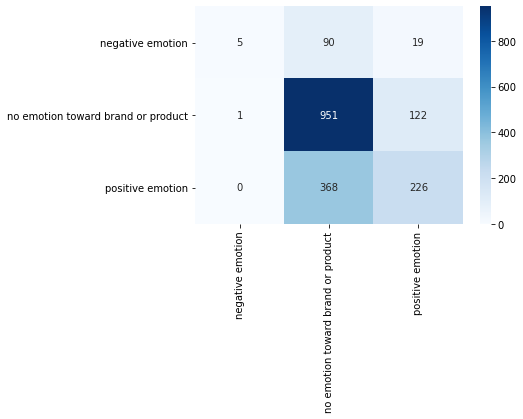

In [ ]:

labels = sorted(y_test.unique())

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_nb, labels=labels)

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

## Evaluation

At this Stage we make a  Summary comparison of all models 

In [ ]:
# Summary comparison of all models
